# Newton Method for Multivariate Optimization

Newton yöntemi, ikinci türev bilgisi (Hessian matrisi) kullanarak bir fonksiyonun minimum noktasını bulan ikinci dereceden bir optimizasyon yöntemidir.

Bu yöntem özellikle konveks ve düzgün (twice differentiable) fonksiyonlarda kuadratik yakınsama hızına sahiptir.

---

## 1. Matematiksel Temel

Bir $f(x, y)$ fonksiyonu için:

### Gradient (Gradyan Vektörü)

$$
\nabla f(x,y) =
\begin{bmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{bmatrix}
$$

---

### Hessian Matrisi

$$
H(x,y) =
\begin{bmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2}
\end{bmatrix}
$$

---

## 2. Newton Güncelleme Kuralı

Newton yöntemi aşağıdaki güncelleme kuralını kullanır:

$$
x_{k+1} = x_k - H^{-1}(x_k)\nabla f(x_k)
$$

Burada:

- $H^{-1}$ : Hessian matrisinin tersi
- $\nabla f$ : Gradient vektörü
- $x_k$ : mevcut nokta

---

## 3. Durdurma Kriteri

Algoritma şu koşul sağlanana kadar devam eder:

$$
\|\Delta x\| < tol
$$

Burada:

$$
\Delta x = H^{-1}\nabla f
$$

---

## 4. Test Fonksiyonu (Quadratic Example)

$$
f(x,y) = x^2 + 2y^2 + xy
$$

Bu fonksiyon konvekstir ve global minimuma sahiptir.

---

## 5. Daha Karmaşık Test Fonksiyonu

$$
f(x,y) = x^4 + y^4 - 4x^2 - 4y^2 + x + y + 20
$$

Bu fonksiyon non-convex yapıdadır ve birden fazla kritik noktaya sahip olabilir.

---

## 6. Yöntemin Özellikleri

- İkinci türev kullanır.
- Kuadratik yakınsama hızına sahiptir.
- Hessian singular ise başarısız olabilir.
- Hesaplama maliyeti: $O(n^3)$ (matris ters alma nedeniyle).

---

## 7. Yöntemin Avantaj ve Dezavantajları

### Avantajlar
- Çok hızlı yakınsar (quadratic convergence).
- Gradient Descent'e göre daha az iterasyon gerektirir.

### Dezavantajlar
- Hessian hesaplama maliyetlidir.
- Büyük boyutlu problemlerde pahalıdır.
- Non-convex fonksiyonlarda saddle point'e gidebilir.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import plotly.graph_objects as go

In [18]:
def Newton_method(f, baslangic, tol=1e-6, max_iter=100):
 
    x_sym, y_sym = sp.symbols('x y')
    ifade = f(x_sym, y_sym)
     
    f_x = ifade.diff(x_sym)
    f_y = ifade.diff(y_sym)
    f_xx = f_x.diff(x_sym)
    f_yy = f_y.diff(y_sym)
    f_xy = f_x.diff(y_sym)
   
    grad_func = sp.lambdify((x_sym, y_sym), [f_x, f_y], 'numpy')
    hess_func = sp.lambdify((x_sym, y_sym), [[f_xx, f_xy], [f_xy, f_yy]], 'numpy')
     
    nokta = np.array(baslangic, dtype=float)
    
    for i in range(max_iter):
  
        g = np.array(grad_func(nokta[0], nokta[1]))
        H = np.array(hess_func(nokta[0], nokta[1]))
     
        try:
            H_inv = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            print("Hessian matrisinin tersi alınamadı (Singular Matrix)!")
            return None
       
        adim = H_inv @ g
        nokta_yeni = nokta - adim
        
        if np.linalg.norm(adim) < tol:
            print(f"Başarılı! {i+1}. iterasyonda minimum bulundu.")
            return nokta_yeni
            
        nokta = nokta_yeni  
        
    print("Maksimum iterasyona ulaşıldı.")
    return nokta

In [19]:
def f(x, y):
    return x**2 + 2*y**2 + x*y

In [20]:
sonuc = Newton_method(f, baslangic=[0.0, 0.0])
print("Minimum nokta:", sonuc)

Başarılı! 1. iterasyonda minimum bulundu.
Minimum nokta: [0. 0.]


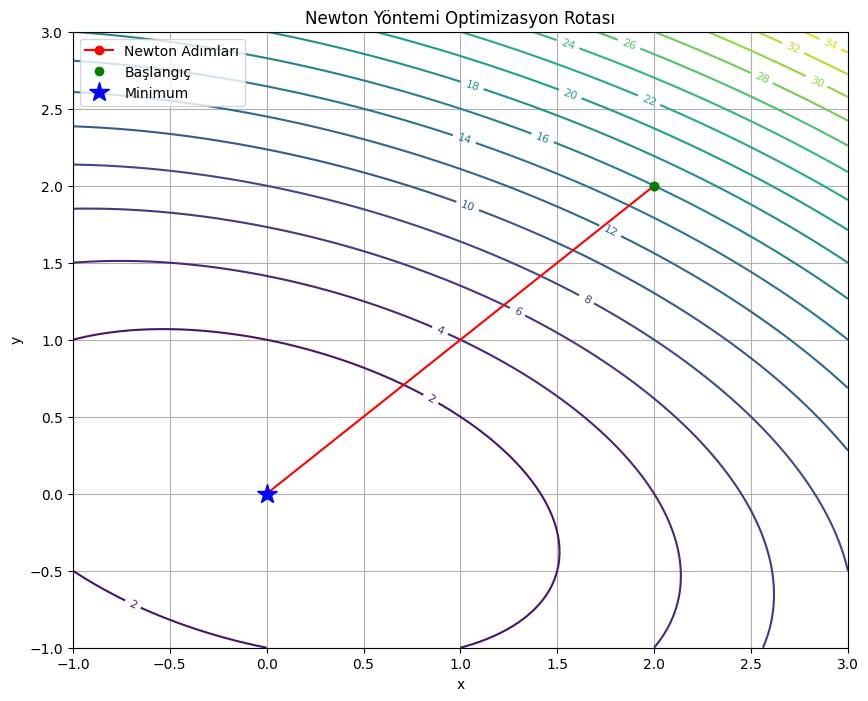

array([0., 0.])

In [21]:
def Newton_method_visual(f, baslangic, tol=1e-6, max_iter=10):
    x_sym, y_sym = sp.symbols('x y')
    ifade = f(x_sym, y_sym)
   
    f_x = ifade.diff(x_sym)
    f_y = ifade.diff(y_sym)
    f_xx = f_x.diff(x_sym)
    f_yy = f_y.diff(y_sym)
    f_xy = f_x.diff(y_sym)
    
    grad_func = sp.lambdify((x_sym, y_sym), [f_x, f_y], 'numpy')
    hess_func = sp.lambdify((x_sym, y_sym), [[f_xx, f_xy], [f_xy, f_yy]], 'numpy')
    f_num = sp.lambdify((x_sym, y_sym), ifade, 'numpy')

    nokta = np.array(baslangic, dtype=float)
    gecmis = [nokta.copy()]  

 
    for i in range(max_iter):
        g = np.array(grad_func(nokta[0], nokta[1]))
        H = np.array(hess_func(nokta[0], nokta[1]))
        
        adim = np.linalg.inv(H) @ g
        nokta = nokta - adim
        gecmis.append(nokta.copy())
        
        if np.linalg.norm(adim) < tol:
            break

  
    gecmis = np.array(gecmis)
    x_range = np.linspace(min(gecmis[:,0])-1, max(gecmis[:,0])+1, 100)
    y_range = np.linspace(min(gecmis[:,1])-1, max(gecmis[:,1])+1, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = f_num(X, Y)

    plt.figure(figsize=(10, 8))
    cp = plt.contour(X, Y, Z, levels=20, cmap='viridis')  
    plt.clabel(cp, inline=True, fontsize=8)
    
     
    plt.plot(gecmis[:,0], gecmis[:,1], 'ro-', label='Newton Adımları')
    plt.plot(gecmis[0,0], gecmis[0,1], 'go', label='Başlangıç')
    plt.plot(gecmis[-1,0], gecmis[-1,1], 'b*', markersize=15, label='Minimum')
    
    plt.title("Newton Yöntemi Optimizasyon Rotası")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

    return nokta

# Test
def test_f(x, y): return x**2 + 2*y**2 + x*y
Newton_method_visual(test_f, [2, 2])

In [22]:
def newton_visual_plotly(f, baslangic, iter_sayisi=5):
  
    x_s, y_s = sp.symbols('x y')
    ifade = f(x_s, y_s)
    f_num = sp.lambdify((x_s, y_s), ifade, 'numpy')
  
    gecmis_x = [baslangic[0]]
    gecmis_y = [baslangic[1]]
    gecmis_z = [f_num(baslangic[0], baslangic[1])]
    
    x_range = np.linspace(-5, 5, 100)
    y_range = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = f_num(X, Y)
 
    fig = go.Figure()
 
    fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale='Viridis', opacity=0.7, name='Fonksiyon Yüzeyi'))
 
    fig.add_trace(go.Scatter3d(
        x=gecmis_x, y=gecmis_y, z=gecmis_z,
        mode='lines+markers',
        marker=dict(size=6, color='red', symbol='circle'),
        line=dict(color='red', width=4),
        name='Newton Rotası'
    ))
 
    fig.update_layout(
        title='Newton Yöntemi: İnteraktif 3D Optimizasyon Rotası',
        scene=dict(
            xaxis_title='X Ekseni',
            yaxis_title='Y Ekseni',
            zaxis_title='f(x, y)'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()
 

In [23]:
def test_f(x, y): return x**4 + y**4 - 4*x**2 - 4*y**2 + x + y + 20
sonuc = newton_visual_plotly(test_f, [2.2, 2.2])
print("Minimum nokta:", sonuc)

Minimum nokta: None
